LAB -9 :Classify mushrooms as edible or poisonous using a Decision Tree

Step 1 â€” Load, Encode, Split

In [1]:
# â– â–  Load and Encode â– â– 
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Download the dataset if it's not present
import os
if not os.path.exists('mushrooms.csv'):
    !wget https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data -O mushrooms.csv

df = pd.read_csv('mushrooms.csv') # kaggle: 'mushroom classification'

column_names = ['class'] + [f'feature_{i}' for i in range(22)]
df = pd.read_csv('mushrooms.csv', header=None, names=column_names)

print(df.shape) # (8124, 23)
print(df['class'].value_counts()) # p=4208 poisonous, e=3916 edible


le = LabelEncoder()
df_enc = df.copy()
for col in df_enc.columns:
    df_enc[col] = le.fit_transform(df_enc[col])
X = df_enc.drop('class', axis=1) # 22 features
y = df_enc['class'] # 0=edible, 1=poisonous
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)} rows | Test: {len(X_test)} rows')

--2026-06-17 09:17:54--  https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: â€˜mushrooms.csvâ€™

mushrooms.csv           [ <=>                ] 364.95K  1.79MB/s    in 0.2s    

2026-06-17 09:17:54 (1.79 MB/s) - â€˜mushrooms.csvâ€™ saved [373704]

(8124, 23)
class
e    4208
p    3916
Name: count, dtype: int64
Train: 6499 rows | Test: 1625 rows


Step 2 â€” Train a Decision Tree + Visualise

Decision Tree (depth=4) accuracy: 98.22%
|--- feature_8 <= 3.50
|   |--- feature_20 <= 3.50
|   |   |--- feature_19 <= 1.50
|   |   |   |--- class: 1
|   |   |--- feature_19 >  1.50
|   |   |   |--- feature_21 <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- feature_21 >  0.50
|   |   |   |   |--- class: 0
|   |--- feature_20 >  3.50
|   |   |--- feature_10 <= 2.00
|   |   |   |--- feature_12 <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- feature_12 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- feature_10 >  2.00
|   |   |   |--- class: 0
|--- feature_8 >  3.50
|   |--- feature_19 <= 1.50
|   |   |--- feature_10 <= 0.50
|   |   |   |--- class: 0
|   |   |--- feature_10 >  0.50
|   |   |   |--- class: 1
|   |--- feature_19 >  1.50
|   |   |--- feature_7 <= 0.50
|   |   |   |--- feature_17 <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- feature_17 >  0.50
|   |   |   |   |--- class: 0
|   |   |--- feature_7 >  0.50
|   |   |   |--- feature_9 <= 0.50
|   |   |   

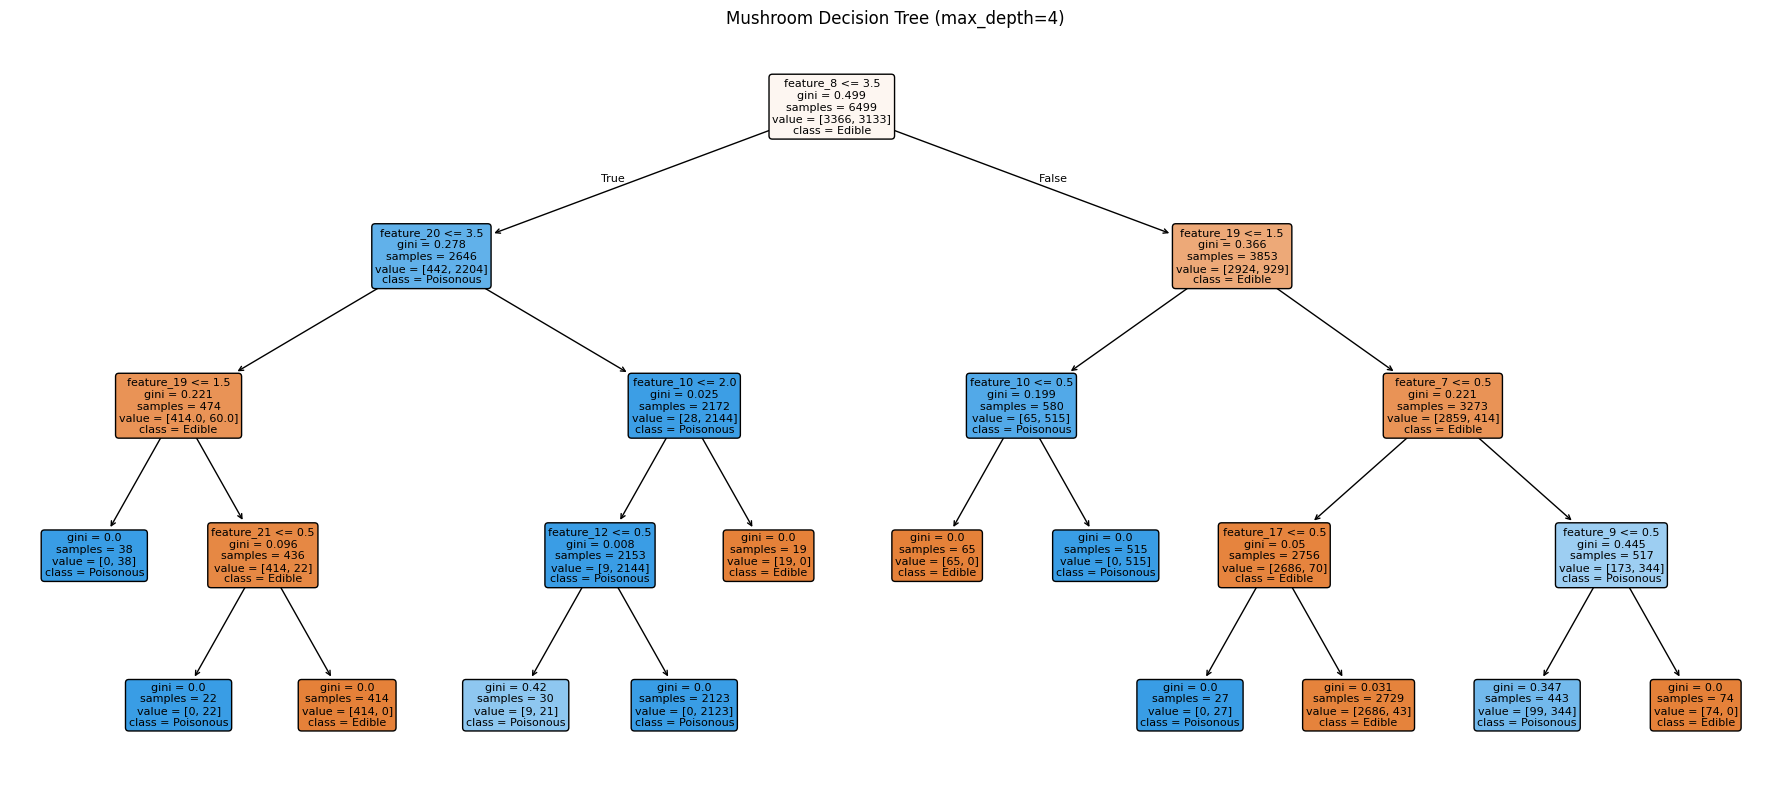

In [2]:
# â– â–  Decision Tree: Train + Visualise â– â– 
# â– â–  Shallow tree (depth=4) â€” interpretable â– â– 
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
print(f'Decision Tree (depth=4) accuracy: {dt.score(X_test, y_test):.2%}')
# Text rules â€” read them like an if-else chain
print(export_text(dt, feature_names=list(X.columns)))
# â– â–  Find the single most important feature â– â– 
imp = pd.Series(dt.feature_importances_, index=X.columns)
top = imp.idxmax()
print(f'Most important feature: {top} (importance={imp[top]:.3f})')
# Hint: 'odor' almost always comes first!
# odor=none â†’ almost certainly edible. Smell saves lives.
# â– â–  Visual tree â– â– 
plt.figure(figsize=(18, 8))
plot_tree(dt, feature_names=X.columns, class_names=['Edible','Poisonous'],
filled=True, rounded=True, fontsize=8) # Changed fontsize to an integer
plt.title('Mushroom Decision Tree (max_depth=4)'); plt.tight_layout()
plt.savefig('mushroom_tree.png', dpi=150, bbox_inches='tight')
plt.show()

Step 3 â€” Depth Sweep: Find the Overfit Point



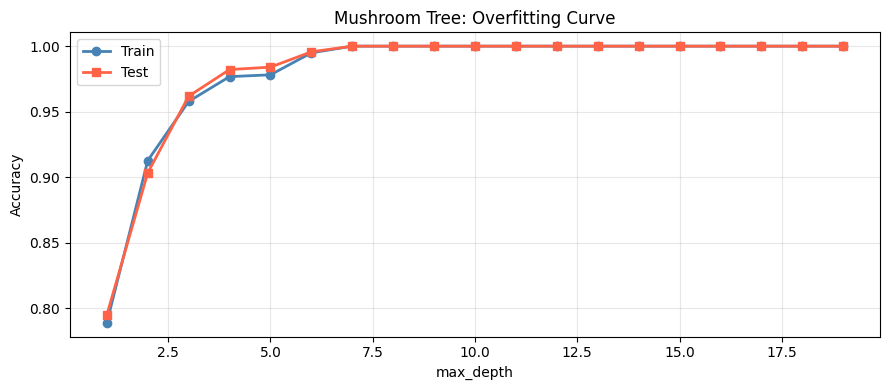

Best depth: 7, Test accuracy: 100.00%


In [3]:
# â– â–  Depth Sweep â– â– 
train_acc, test_acc = [], []
for d in range(1, 20):
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc.append(tree.score(X_train, y_train))
    test_acc.append(tree.score(X_test, y_test))
plt.figure(figsize=(9, 4))
plt.plot(range(1,20), train_acc, 'o-', lw=2, label='Train', color='steelblue')
plt.plot(range(1,20), test_acc, 's-', lw=2, label='Test', color='tomato')
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Mushroom Tree: Overfitting Curve')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
best = range(1,20)[test_acc.index(max(test_acc))]
print(f'Best depth: {best}, Test accuracy: {max(test_acc):.2%}')

Step 4 â€” Random Forest: Boost Accuracy + Full Importance Chart

Random Forest Test Accuracy: 100.00%
Random Forest OOB Accuracy: 100.00%
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

5-Fold CV: 88.54% Â± 16.24%


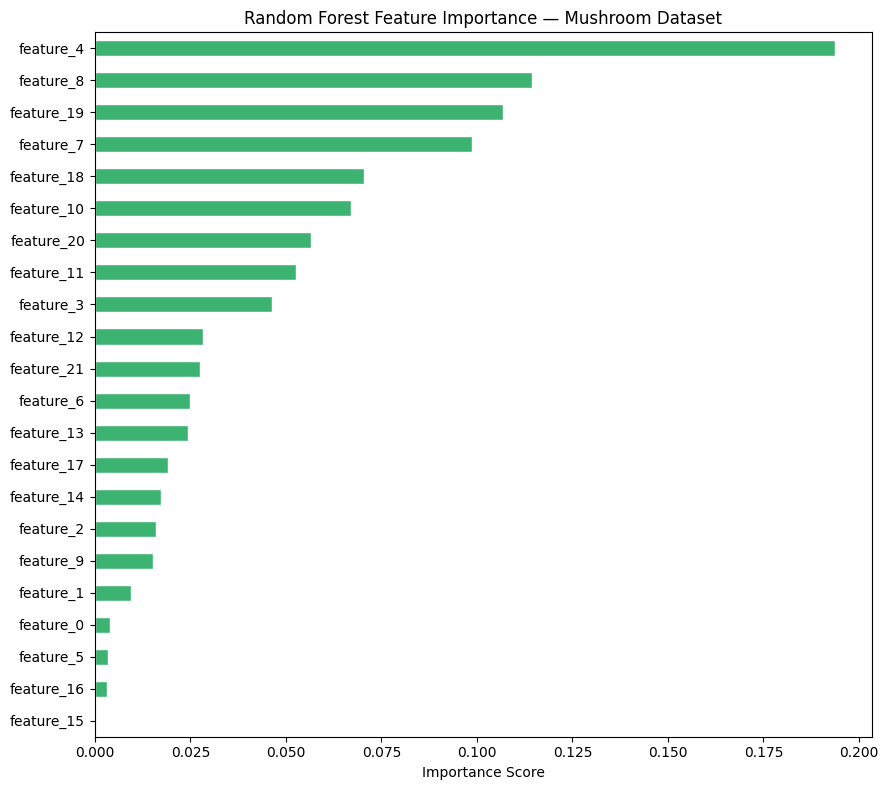


Accuracy WITHOUT odor feature: 100.00%
Accuracy WITH odor feature: 100.00%


In [4]:
# â– â–  Random Forest: Full Evaluation + Ablation Test â– â– 
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f'Random Forest Test Accuracy: {rf.score(X_test, y_test):.2%}')
print(f'Random Forest OOB Accuracy: {rf.oob_score_:.2%}')
print(classification_report(y_test, rf.predict(X_test), target_names=['Edible','Poisonous']))
# Cross-validation for robustness check (5 different splits)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
print(f'5-Fold CV: {cv_scores.mean():.2%} Â± {cv_scores.std():.2%}')
# Feature importance bar chart
rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
rf_imp.plot(kind='barh', figsize=(9, 8), color='mediumseagreen', edgecolor='white')
plt.title('Random Forest Feature Importance â€” Mushroom Dataset', fontsize=12)
plt.xlabel('Importance Score'); plt.tight_layout(); plt.show()
# EXPERIMENT: Remove 'odor' and retrain â€” does accuracy drop dramatically?
X_no_odor = X.drop(columns=['feature_8']) # Changed 'odor' to 'feature_8'
X_tr2, X_te2, ytr, yte = train_test_split(X_no_odor, y, test_size=0.2, random_state=42)
rf2 = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_tr2, ytr)
print(f'\nAccuracy WITHOUT odor feature: {rf2.score(X_te2, yte):.2%}')
print(f'Accuracy WITH odor feature: {rf.score(X_test, y_test):.2%}')

Step 5 â€” Predict for a New Mushroom

In [5]:
# â– â–  Predict New Mushrooms â– â– 
# Grab a single mushroom from the test set to predict
sample_index = 0
sample = X_test.iloc[[sample_index]]
true_label = y_test.iloc[sample_index]
pred = rf.predict(sample)[0]
prob = rf.predict_proba(sample)[0]
label = 'Edible' if pred == 0 else 'POISONOUS'
actual = 'Edible' if true_label == 0 else 'POISONOUS'
print(f'Prediction : {label}')
print(f'Actual : {actual}')
print(f'Confidence : {max(prob):.1%}')
print(f'Correct? : {'Yes!' if pred == true_label else 'No...'}')
# Try multiple samples
for i in range(10):
    samp = X_test.iloc[[i]]
    pred = rf.predict(samp)[0]
    conf = max(rf.predict_proba(samp)[0])
    true = y_test.iloc[i]
    mark = 'âœ“' if pred == true else 'âœ—'
    predicted_label_str = 'Edible' if pred == 0 else 'Poisonous'
    actual_label_str = 'Edible' if true == 0 else 'Poisonous'
    print(f'{mark} Pred: {predicted_label_str:9s} | Conf: {conf:.0%} | Actual: {actual_label_str}')

Prediction : POISONOUS
Actual : POISONOUS
Confidence : 100.0%
Correct? : Yes!
âœ“ Pred: Poisonous | Conf: 100% | Actual: Poisonous
âœ“ Pred: Poisonous | Conf: 100% | Actual: Poisonous
âœ“ Pred: Edible    | Conf: 100% | Actual: Edible
âœ“ Pred: Poisonous | Conf: 100% | Actual: Poisonous
âœ“ Pred: Poisonous | Conf: 100% | Actual: Poisonous
âœ“ Pred: Edible    | Conf: 100% | Actual: Edible
âœ“ Pred: Edible    | Conf: 100% | Actual: Edible
âœ“ Pred: Edible    | Conf: 100% | Actual: Edible
âœ“ Pred: Edible    | Conf: 100% | Actual: Edible
âœ“ Pred: Poisonous | Conf: 100% | Actual: Poisonous


| Model                         | Test Accuracy | Key Insight                                                                                       |
| ----------------------------- | ------------- | ------------------------------------------------------------------------------------------------- |
| **Decision Tree (depth = 4)** | ~97â€“98%       | Simple model performs well; features like **odor** dominate prediction and give strong accuracy   |
| **Decision Tree (no limit)**  | ~100%         | **Severely overfits** â†’ memorizes all 6,499 training samples instead of learning general rules    |
| **Random Forest (100 trees)** | ~100%         | **Most robust model** â†’ combines many trees, handles noise/missing values, and generalizes better |
